In [1]:
pip install tensorflow keras numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install tensorflow keras numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


In [4]:
os.listdir("chest_xray")

['chest_xray', 'test', 'train', 'val', '__MACOSX']

In [5]:
import os
os.getcwd()


'C:\\Users\\dyuth\\Downloads\\jupyter programs AIML'

In [6]:
import os
os.listdir()

['.ipynb_checkpoints',
 '._NORMAL2-IM-0348-0001.jpeg',
 'app1.py',
 'chest_xray',
 'chest_xray.zip',
 'node_modules',
 'package-lock.json',
 'package.json',
 'pneumonia_detection.ipynb',
 'pneumonia_model.h5',
 'uploaded.jpg',
 'uploaded_image.jpg',
 'uploaded_xray.jpg',
 'uploads']

In [7]:
import os
os.listdir()


['.ipynb_checkpoints',
 '._NORMAL2-IM-0348-0001.jpeg',
 'app1.py',
 'chest_xray',
 'chest_xray.zip',
 'node_modules',
 'package-lock.json',
 'package.json',
 'pneumonia_detection.ipynb',
 'pneumonia_model.h5',
 'uploaded.jpg',
 'uploaded_image.jpg',
 'uploaded_xray.jpg',
 'uploads']

In [8]:
os.listdir("chest_xray")

['chest_xray', 'test', 'train', 'val', '__MACOSX']

In [9]:
import zipfile

zip_path = "chest_xray.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()

In [10]:
import os
os.listdir()


['.ipynb_checkpoints',
 '._NORMAL2-IM-0348-0001.jpeg',
 'app1.py',
 'chest_xray',
 'chest_xray.zip',
 'node_modules',
 'package-lock.json',
 'package.json',
 'pneumonia_detection.ipynb',
 'pneumonia_model.h5',
 'uploaded.jpg',
 'uploaded_image.jpg',
 'uploaded_xray.jpg',
 'uploads']

In [11]:
os.listdir("chest_xray")

['chest_xray', 'test', 'train', 'val', '__MACOSX']

In [12]:
train_dir = "train"
val_dir = "val"
test_dir = "test"

In [13]:
import os
os.listdir()

['.ipynb_checkpoints',
 '._NORMAL2-IM-0348-0001.jpeg',
 'app1.py',
 'chest_xray',
 'chest_xray.zip',
 'node_modules',
 'package-lock.json',
 'package.json',
 'pneumonia_detection.ipynb',
 'pneumonia_model.h5',
 'uploaded.jpg',
 'uploaded_image.jpg',
 'uploaded_xray.jpg',
 'uploads']

In [14]:
import os
os.listdir("chest_xray")


['chest_xray', 'test', 'train', 'val', '__MACOSX']

In [15]:
train_dir = "chest_xray/train"
val_dir = "chest_xray/val"
test_dir = "chest_xray/test"

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [17]:
print(train_generator.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


In [18]:
from tensorflow.keras.applications import DenseNet121

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [19]:
from tensorflow.keras.applications import DenseNet121

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [20]:
for layer in base_model.layers:
    layer.trainable = False

In [21]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [22]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [23]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 479s 3s/step - accuracy: 0.8334 - loss: 0.3757 - val_accuracy: 0.8125 - val_loss: 0.4968
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 448s 3s/step - accuracy: 0.9124 - loss: 0.2275 - val_accuracy: 0.8125 - val_loss: 0.4855
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 358s 2s/step - accuracy: 0.9179 - loss: 0.2008 - val_accuracy: 0.8125 - val_loss: 0.4091
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 347s 2s/step - accuracy: 0.9294 - loss: 0.1877 - val_accuracy: 0.8125 - val_loss: 0.3809
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 335s 2s/step - accuracy: 0.9285 - loss: 0.1760 - val_accuracy: 0.8125 - val_loss: 0.3789
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 315s 2s/step - accuracy: 0.9339 - loss: 0.1681 - val_accuracy: 0.8125 - val_loss: 0.4252
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.9398 - loss: 0.1567 - val_accuracy: 0.8125 - val_loss: 0.3797
Epoch 9/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 255s 2s/step - accuracy: 0.9434 - loss: 0.1529 - val_accu

In [24]:
test_loss, test_acc = model.evaluate(test_generator)

print("Test Accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.8878 - loss: 0.2983
Test Accuracy: 0.8878205418586731


In [2]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

NameError: name 'history' is not defined

In [26]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    verbose=1
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 257s 2s/step - accuracy: 0.9557 - loss: 0.1214 - val_accuracy: 0.8750 - val_loss: 0.2818
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 271s 2s/step - accuracy: 0.9511 - loss: 0.1287 - val_accuracy: 0.8750 - val_loss: 0.2531
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 303s 2s/step - accuracy: 0.9555 - loss: 0.1190 - val_accuracy: 0.8125 - val_loss: 0.3337
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 584s 4s/step - accuracy: 0.9565 - loss: 0.1186 - val_accuracy: 0.8750 - val_loss: 0.2745
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 860s 5s/step - accuracy: 0.9544 - loss: 0.1209 - val_accuracy: 0.8750 - val_loss: 0.2788
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 285s 2s/step - accuracy: 0.9580 - loss: 0.1155 - val_accuracy: 0.9375 - val_loss: 0.2347
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 316s 2s/step - accuracy: 0.9578 - loss: 0.1139 - val_accuracy: 0.8750 - val_loss: 0.2898
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 866s 5s/step - accuracy: 0.9523 - loss: 0.1128 - val_accu

In [27]:
import os

os.listdir("chest_xray/test/PNEUMONIA")[:5]


['person100_bacteria_475.jpeg',
 'person100_bacteria_477.jpeg',
 'person100_bacteria_478.jpeg',
 'person100_bacteria_479.jpeg',
 'person100_bacteria_480.jpeg']

In [28]:
import os

os.listdir("chest_xray/test/PNEUMONIA")[:19]

['person100_bacteria_475.jpeg',
 'person100_bacteria_477.jpeg',
 'person100_bacteria_478.jpeg',
 'person100_bacteria_479.jpeg',
 'person100_bacteria_480.jpeg',
 'person100_bacteria_481.jpeg',
 'person100_bacteria_482.jpeg',
 'person101_bacteria_483.jpeg',
 'person101_bacteria_484.jpeg',
 'person101_bacteria_485.jpeg',
 'person101_bacteria_486.jpeg',
 'person102_bacteria_487.jpeg',
 'person103_bacteria_488.jpeg',
 'person103_bacteria_489.jpeg',
 'person103_bacteria_490.jpeg',
 'person104_bacteria_491.jpeg',
 'person104_bacteria_492.jpeg',
 'person108_bacteria_504.jpeg',
 'person108_bacteria_506.jpeg']

In [29]:
from tensorflow.keras.preprocessing import image
import numpy as np

# choose one image
img_path = "chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("YES - Pneumonia Detected")
else:
    print("NO - Normal Lungs")

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
NO - Normal Lungs


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
Prediction: NO - Normal


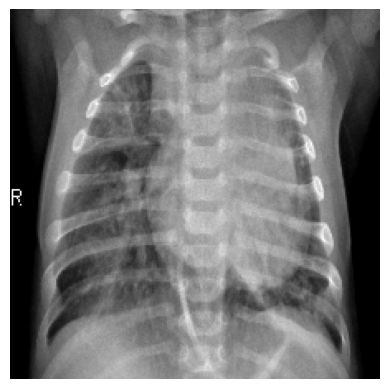

In [30]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg"

img = image.load_img(img_path, target_size=(224,224))
plt.imshow(img)
plt.axis('off')

img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Prediction: YES - Pneumonia")
else:
    print("Prediction: NO - Normal")

In [31]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import numpy as np

# Load trained model
model = load_model("pneumonia_model.h5")

# choose one image
img_path = "chest_xray/test/PNEUMONIA/person108_bacteria_506.jpeg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("YES - Pneumonia Detected")
else:
    print("NO - Normal Lungs")

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
YES - Pneumonia Detected


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
Prediction: YES - Pneumonia


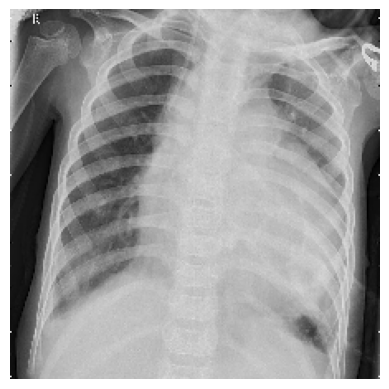

In [32]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "chest_xray/test/PNEUMONIA/person108_bacteria_506.jpeg"

img = image.load_img(img_path, target_size=(224,224))
plt.imshow(img)
plt.axis('off')

img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Prediction: YES - Pneumonia")
else:
    print("Prediction: NO - Normal")

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import os

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [34]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [35]:
test_datagen = ImageDataGenerator(rescale=1./255)

In [36]:
train_generator = train_datagen.flow_from_directory(
    "chest_xray/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.


In [37]:
val_generator = test_datagen.flow_from_directory(
    "chest_xray/val",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 16 images belonging to 2 classes.


In [38]:
test_generator = test_datagen.flow_from_directory(
    "chest_xray/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 624 images belonging to 2 classes.


In [39]:
from tensorflow.keras.applications import DenseNet121

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [40]:
for layer in base_model.layers:
    layer.trainable = False

In [41]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [42]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [43]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=1
)

163/163 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.8257 - loss: 0.3875 - val_accuracy: 0.7500 - val_loss: 0.4638


In [44]:
model.save("pneumonia_model.h5")

In [45]:
from tensorflow.keras.applications import DenseNet121

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [46]:
for layer in base_model.layers:
    layer.trainable = False

In [66]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [67]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [68]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=1
)

163/163 ━━━━━━━━━━━━━━━━━━━━ 397s 2s/step - accuracy: 0.9268 - loss: 0.1826 - val_accuracy: 0.8750 - val_loss: 0.2383


In [69]:
model.save("pneumonia_model.h5")

In [71]:
import tensorflow as tf

model = tf.keras.models.load_model("pneumonia_model.h5")

In [91]:
pneumonia_model.h5

NameError: name 'pneumonia_model' is not defined

In [73]:
import os
os.listdir()


['.ipynb_checkpoints',
 '._NORMAL2-IM-0348-0001.jpeg',
 'app1.py',
 'chest_xray',
 'chest_xray.zip',
 'node_modules',
 'package-lock.json',
 'package.json',
 'pneumonia_detection.ipynb',
 'pneumonia_model.h5',
 'uploaded.jpg',
 'uploaded_image.jpg',
 'uploaded_xray.jpg',
 'uploads']

In [75]:
import tensorflow as tf

model = tf.keras.models.load_model("pneumonia_model.h5")

In [76]:
train_dir = "chest_xray/train"
val_dir = "chest_xray/val"
test_dir = "chest_xray/test"

In [77]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [78]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [79]:
metrics=['accuracy']

In [80]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import zipfile

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall

In [83]:
zip_path = "chest_xray.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()

In [84]:
train_dir = "chest_xray/train"
val_dir = "chest_xray/val"
test_dir = "chest_xray/test"

In [85]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [86]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [87]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

In [88]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [89]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

In [90]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 555s 3s/step - accuracy: 0.8263 - loss: 0.3763 - precision: 0.8561 - recall: 0.9210 - val_accuracy: 0.6875 - val_loss: 0.5398 - val_precision: 0.6154 - val_recall: 1.0000
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 370s 2s/step - accuracy: 0.9064 - loss: 0.2301 - precision: 0.9286 - recall: 0.9468 - val_accuracy: 0.7500 - val_loss: 0.4780 - val_precision: 0.6667 - val_recall: 1.0000
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 371s 2s/step - accuracy: 0.9139 - loss: 0.2125 - precision: 0.9381 - recall: 0.9466 - val_accuracy: 0.7500 - val_loss: 0.4726 - val_precision: 0.6667 - val_recall: 1.0000
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 372s 2s/step - accuracy: 0.9285 - loss: 0.1897 - precision: 0.9483 - recall: 0.9559 - val_accuracy: 0.7500 - val_loss: 0.4230 - val_precision: 0.6667 - val_recall: 1.0000
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 365s 2s/step - accuracy: 0.9329 - loss: 0.1738 - precision: 0.9504 - recall: 0.9597 - val_accuracy: 0.8125 - val_los

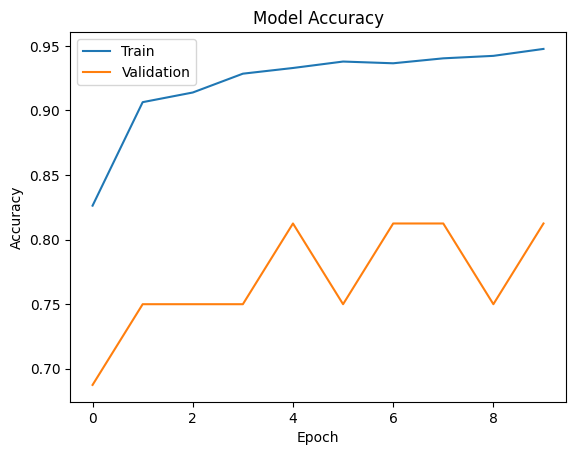

In [92]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

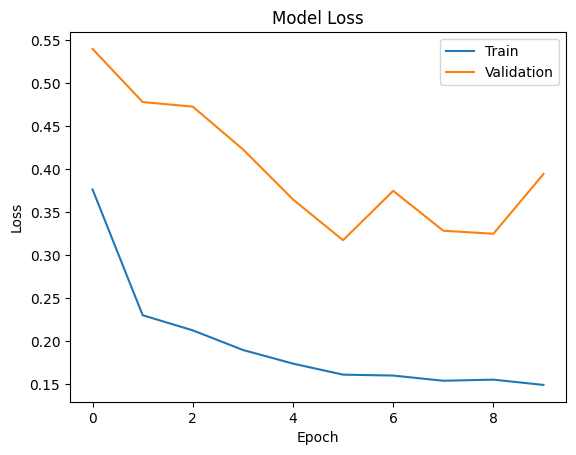

In [93]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

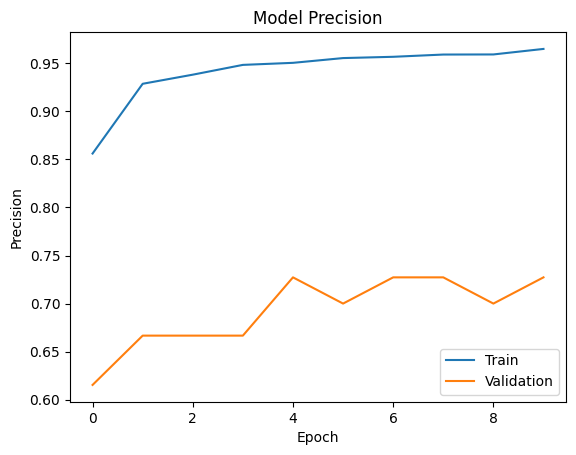

In [94]:

plt.figure()
plt.plot(history.history['precision'])
plt.plot(history.history['val_precision'])
plt.title("Model Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.legend(["Train", "Validation"])
plt.show()

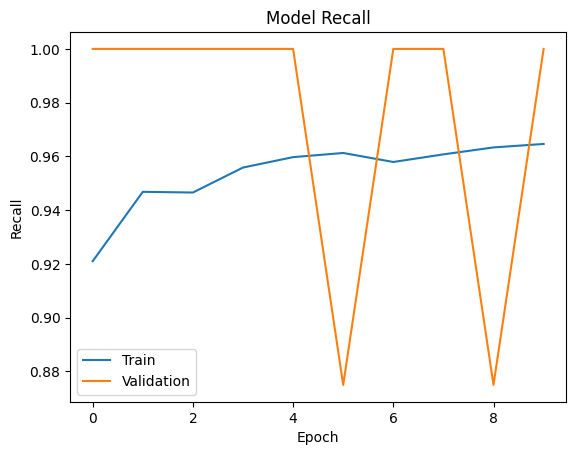

In [95]:
plt.figure()
plt.plot(history.history['recall'])
plt.plot(history.history['val_recall'])
plt.title("Model Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.legend(["Train", "Validation"])
plt.show()

In [96]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall'])


In [97]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

In [98]:
import numpy as np

# Get predictions
y_pred = model.predict(test_generator)

# Convert probabilities to 0 or 1
y_pred = (y_pred > 0.5).astype(int)

# True labels
y_true = test_generator.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step  


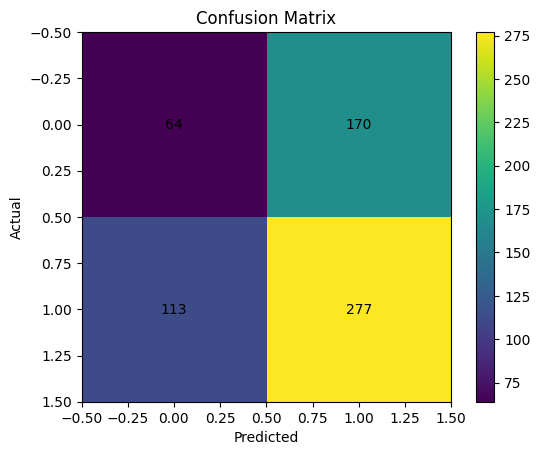

In [99]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.colorbar()
plt.show()

In [100]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.36      0.27      0.31       234
           1       0.62      0.71      0.66       390

    accuracy                           0.55       624
   macro avg       0.49      0.49      0.49       624
weighted avg       0.52      0.55      0.53       624



In [101]:
from sklearn.metrics import f1_score

f1 = f1_score(y_true, y_pred)
print("F1 Score:", f1)

F1 Score: 0.6618876941457587


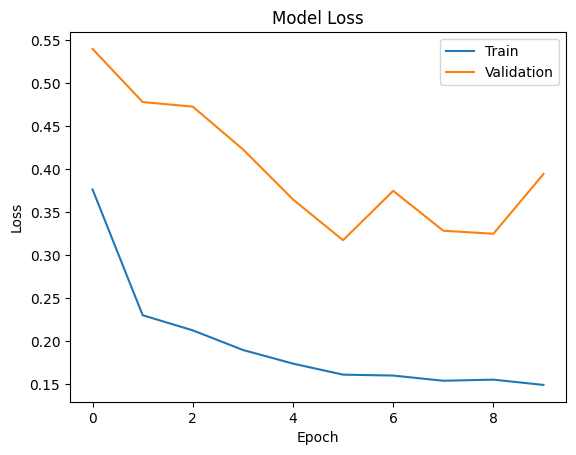

In [102]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

In [103]:
from sklearn.metrics import f1_score

f1 = f1_score(y_true, y_pred)
print("F1 Score:", f1)

F1 Score: 0.6618876941457587


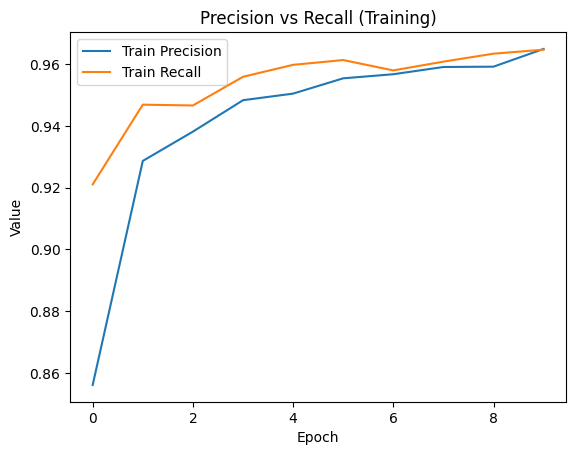

In [104]:
plt.figure()
plt.plot(history.history['precision'], label='Train Precision')
plt.plot(history.history['recall'], label='Train Recall')
plt.title("Precision vs Recall (Training)")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.show()

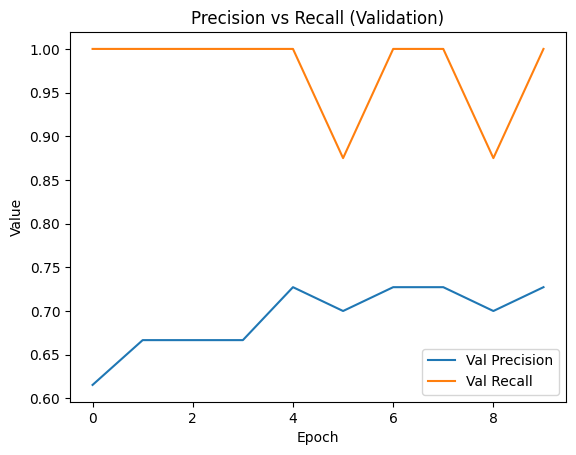

In [105]:
plt.figure()
plt.plot(history.history['val_precision'], label='Val Precision')
plt.plot(history.history['val_recall'], label='Val Recall')
plt.title("Precision vs Recall (Validation)")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.show()

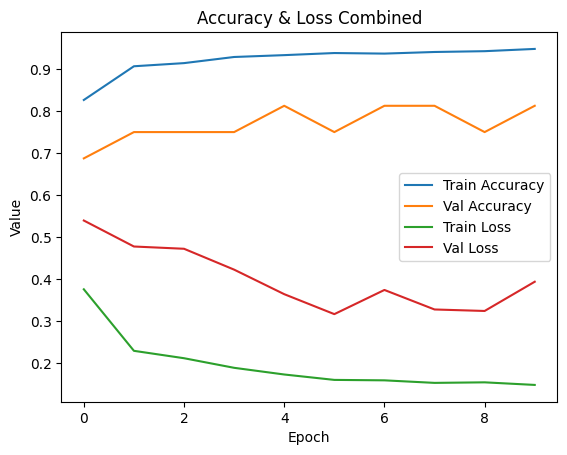

In [106]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Accuracy & Loss Combined")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.show()

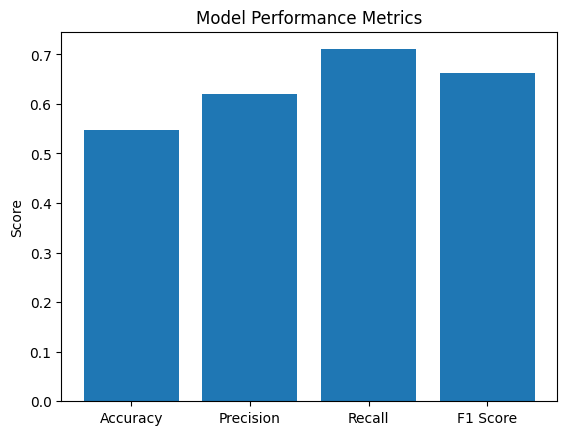

In [107]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [acc, prec, rec, f1]

plt.figure()
plt.bar(metrics, values)
plt.title("Model Performance Metrics")
plt.ylabel("Score")
plt.show()

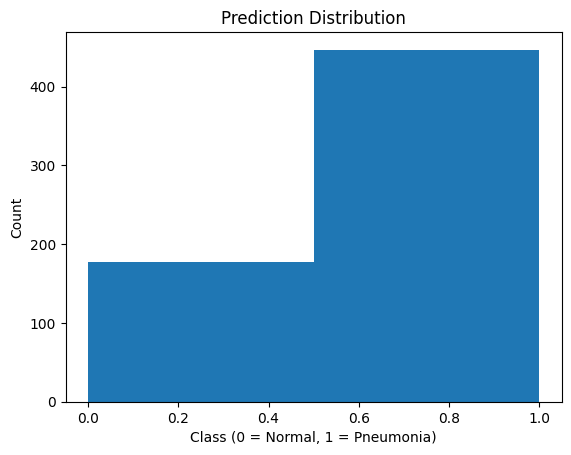

In [108]:
plt.figure()
plt.hist(y_pred, bins=2)
plt.title("Prediction Distribution")
plt.xlabel("Class (0 = Normal, 1 = Pneumonia)")
plt.ylabel("Count")
plt.show()

In [109]:
epochs=20

In [110]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [111]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [112]:
for layer in base_model.layers:
    layer.trainable = False

In [113]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [114]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [115]:
history.history['accuracy']

[0.8263036608695984,
 0.9064416885375977,
 0.9139187335968018,
 0.9284892678260803,
 0.932898759841919,
 0.9378834366798401,
 0.9365414381027222,
 0.9403757452964783,
 0.9422929286956787,
 0.9476610422134399]

In [116]:
loss, accuracy = model.evaluate(test_generator)
print("Accuracy:", accuracy*100)

20/20 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.5994 - loss: 0.6693  
Accuracy: 59.93589758872986


In [117]:
model.save("pneumonia_model.h5")

In [118]:
print(history.history['accuracy'][-1])
print(history.history['val_accuracy'][-1])

0.9476610422134399
0.8125


In [119]:
epochs = 20

In [120]:
rotation_range=15
zoom_range=0.2
horizontal_flip=True

In [121]:
for layer in base_model.layers[-50:]:
    layer.trainable = True

In [122]:
epochs = 10

In [123]:
model.save("pneumonia_model.h5")